---
title: Data Visualization in Python with Seaborn
subtitle: Advanced Data Visualization in Python with Seaborn
abstract: This notebook provides an in-depth introduction to data visualization in Python using the Seaborn library. It explores advanced techniques for creating univariate and bivariate plots, including histograms, scatterplots, line plots, bar plots, and box plots. The notebook emphasizes the importance of visualizing data for exploratory analysis, identifying patterns, and communicating insights effectively. Practical examples and best practices are included to help users create clear, informative, and aesthetically pleasing visualizations.
author:
  - name: Karol Flisikowski
    affiliations: 
      - Gdansk University of Technology
      - Chongqing Technology and Business University
    orcid: 0000-0002-4160-1297
    email: karol@ctbu.edu.cn
date: 2025-04-29
---

## Goals of this lecture

- Introducting `seaborn`. 
- Putting `seaborn` into practice:
  - **Univariate** plots (histograms).  
  - **Bivariate** continuous plots (scatterplots and line plots).
  - **Bivariate** categorical plots (bar plots, box plots, and strip plots).

## Introducing `seaborn`

### What is `seaborn`?

> [`seaborn`](https://seaborn.pydata.org/) is a data visualization library based on `matplotlib`.

- In general, it's easier to make nice-looking graphs with `seaborn`.
- The trade-off is that `matplotlib` offers more flexibility.

In [6]:
import seaborn as sns ### importing seaborn
import pandas as pd
import matplotlib.pyplot as plt ## just in case we need it
import numpy as np

In [7]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

### The `seaborn` hierarchy of plot types

We'll learn more about exactly what this hierarchy means today (and in next lecture).

![title](img/seaborn_library.png)

### Example dataset

Today we'll work with a new dataset, from [Gapminder](https://www.gapminder.org/data/documentation/). 

- **Gapminder** is an independent Swedish foundation dedicated to publishing and analyzing data to correct misconceptions about the world.
- Between 1952-2007, has data about `life_exp`, `gdp_cap`, and `population`.

In [8]:
df_gapminder = pd.read_csv("data/viz/gapminder_full.csv")

In [10]:
df_gapminder.head(3)

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710


In [11]:
df_gapminder.shape

(1704, 6)

## Univariate plots

> A **univariate plot** is a visualization of only a *single* variable, i.e., a **distribution**.

![title](img/displot.png)

### Histograms with `sns.histplot`

- We've produced histograms with `plt.hist`.  
- With `seaborn`, we can use `sns.histplot(...)`.

Rather than use `df['col_name']`, we can use the syntax:

```python
sns.histplot(data = df, x = col_name)
```

This will become even more useful when we start making **bivariate plots**.

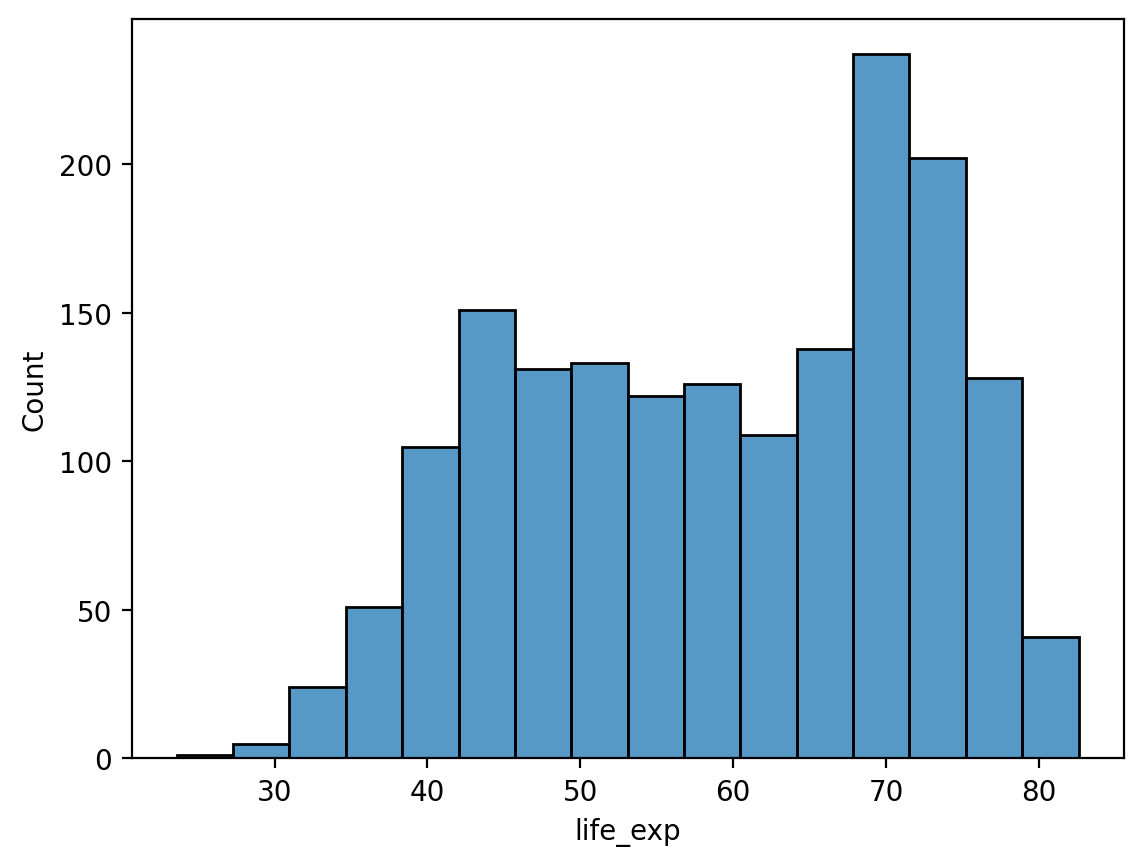

In [8]:
# Histogram of life expectancy
sns.histplot(df_gapminder['life_exp']);

#### Modifying the number of bins

As with `plt.hist`, we can modify the number of *bins*.

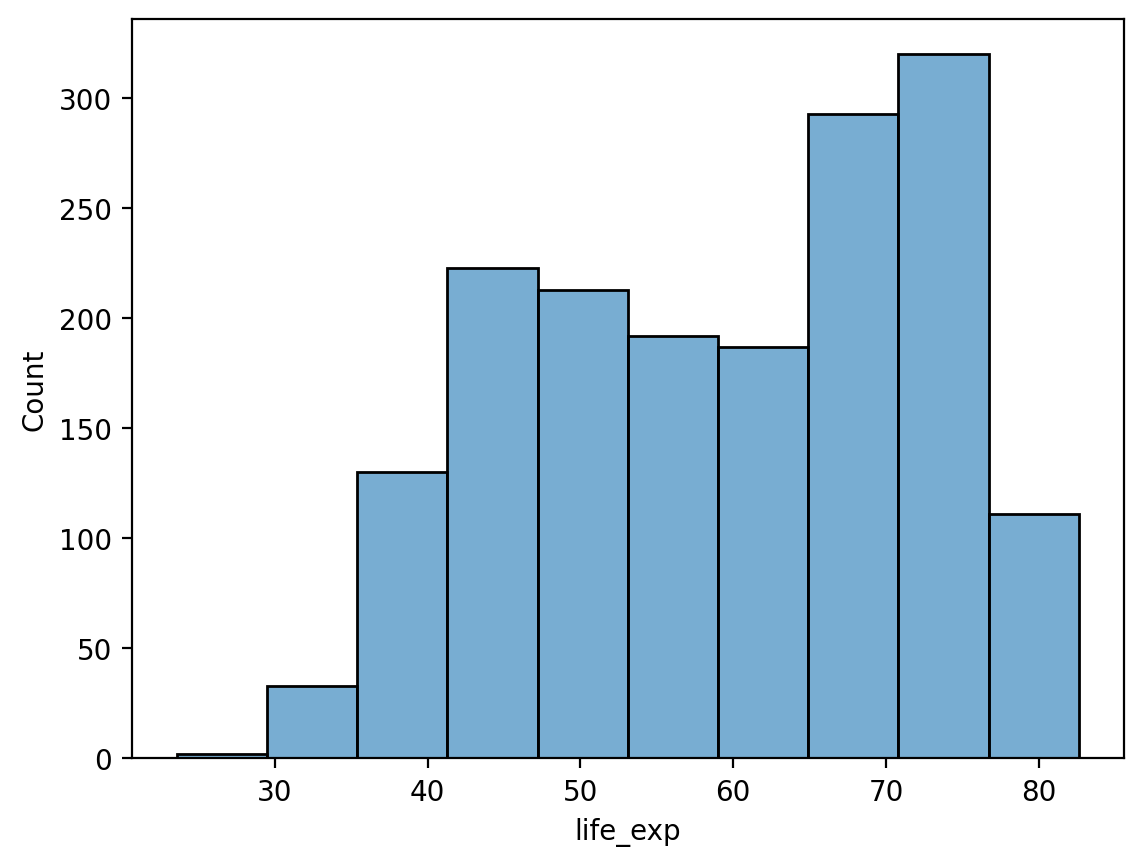

In [9]:
# Fewer bins
sns.histplot(data = df_gapminder, x = 'life_exp', bins = 10, alpha = .6);

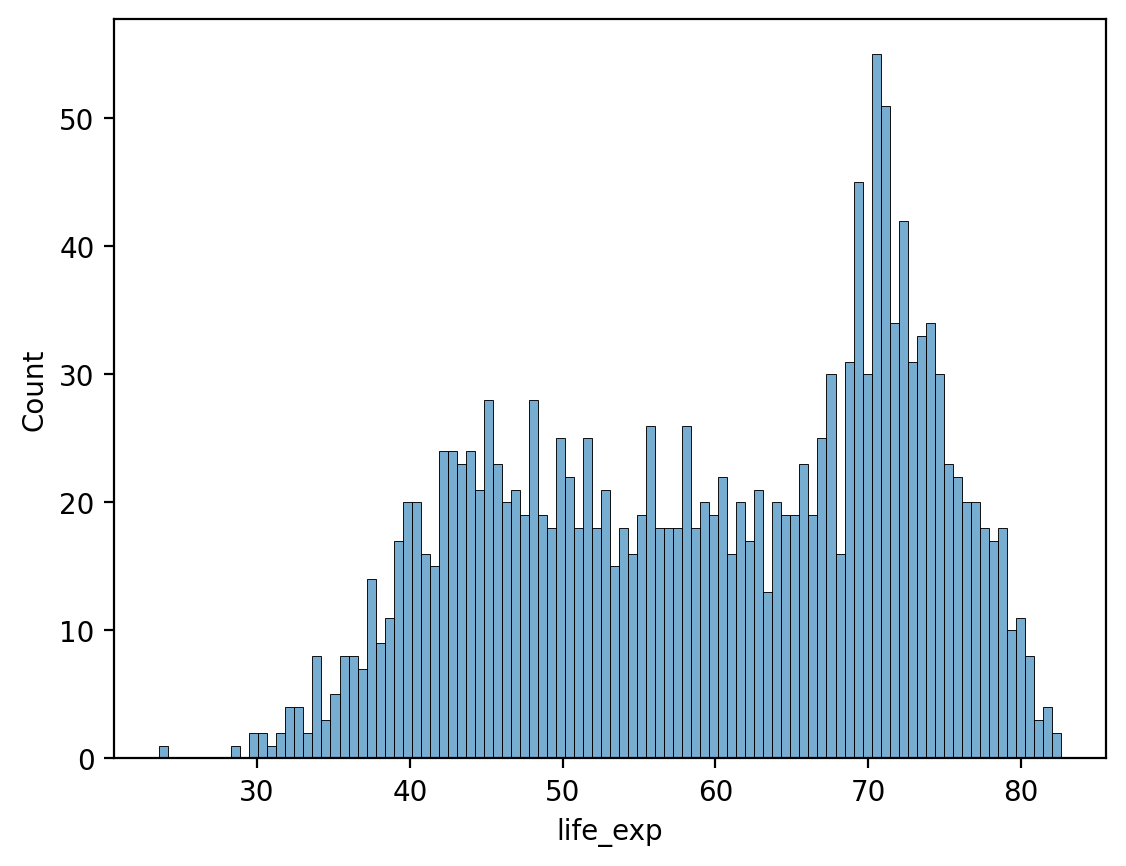

In [10]:
# Many more bins!
sns.histplot(data = df_gapminder, x = 'life_exp', bins = 100, alpha = .6);

#### Modifying the y-axis with `stat`

By default, `sns.histplot` will plot the **count** in each bin. However, we can change this using the `stat` parameter:

- `probability`: normalize such that bar heights sum to `1`.
- `percent`: normalize such that bar heights sum to `100`.
- `density`: normalize such that total *area* sums to `1`.


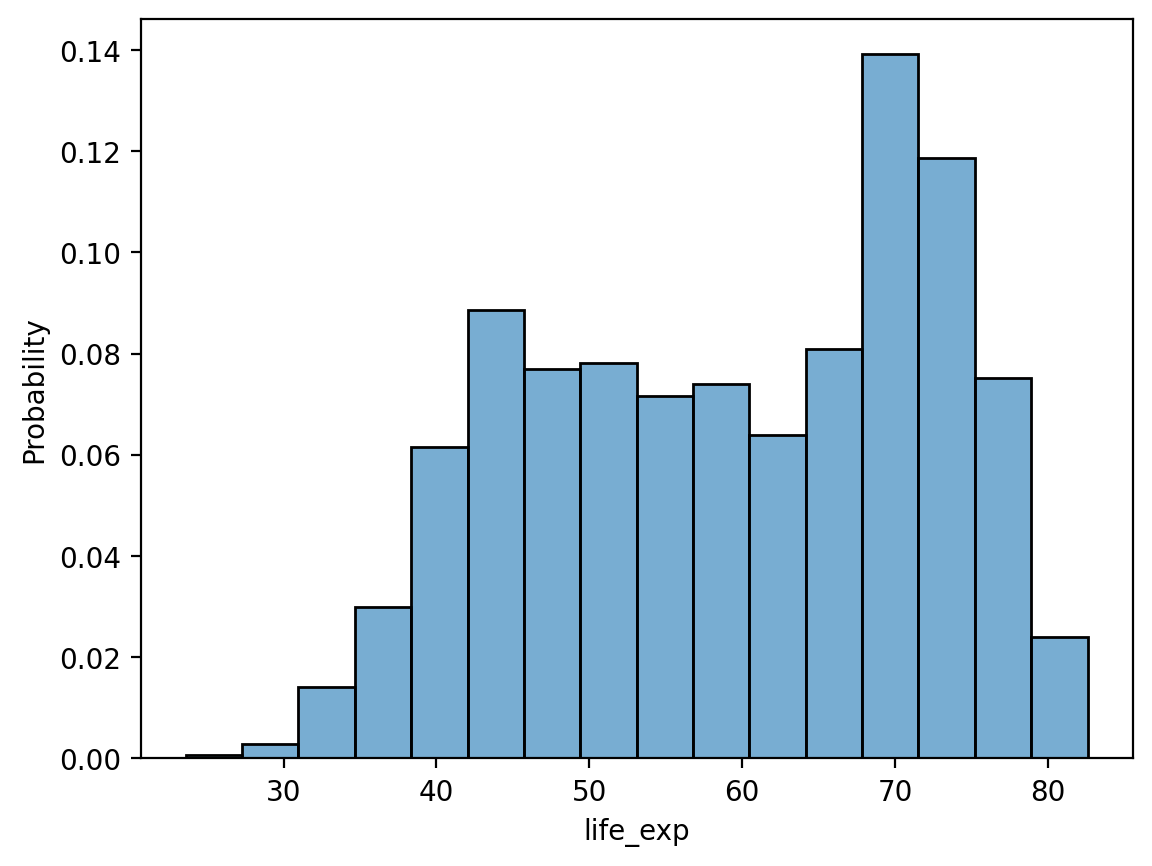

In [12]:
# Note the modified y-axis!
sns.histplot(data = df_gapminder, x = 'life_exp', stat = "probability", alpha = .6);

### Check-in

How would you make a histogram showing the distribution of `population` values in `2007` alone? 

- Bonus 1: Modify this graph to show `probability`, not `count`.
- Bonus 2: What do you notice about this graph, and how might you change it?

In [36]:
### Your code here

In [13]:
# if you really don't know, then see the solution here:
# %load ./solutions/solution8.py

## Bivariate continuous plots

> A **bivariate continuous plot** visualizes the relationship between *two continuous variables*.

![title](img/seaborn_relplot.png)

### Scatterplots with `sns.scatterplot`

> A **scatterplot** visualizes the relationship between two continuous variables.

- Each observation is plotted as a single dot/mark. 
- The position on the `(x, y)` axes reflects the value of those variables.

One way to make a scatterplot in `seaborn` is using `sns.scatterplot`.

#### Showing `gdp_cap` by `life_exp`

What do we notice about `gdp_cap`?

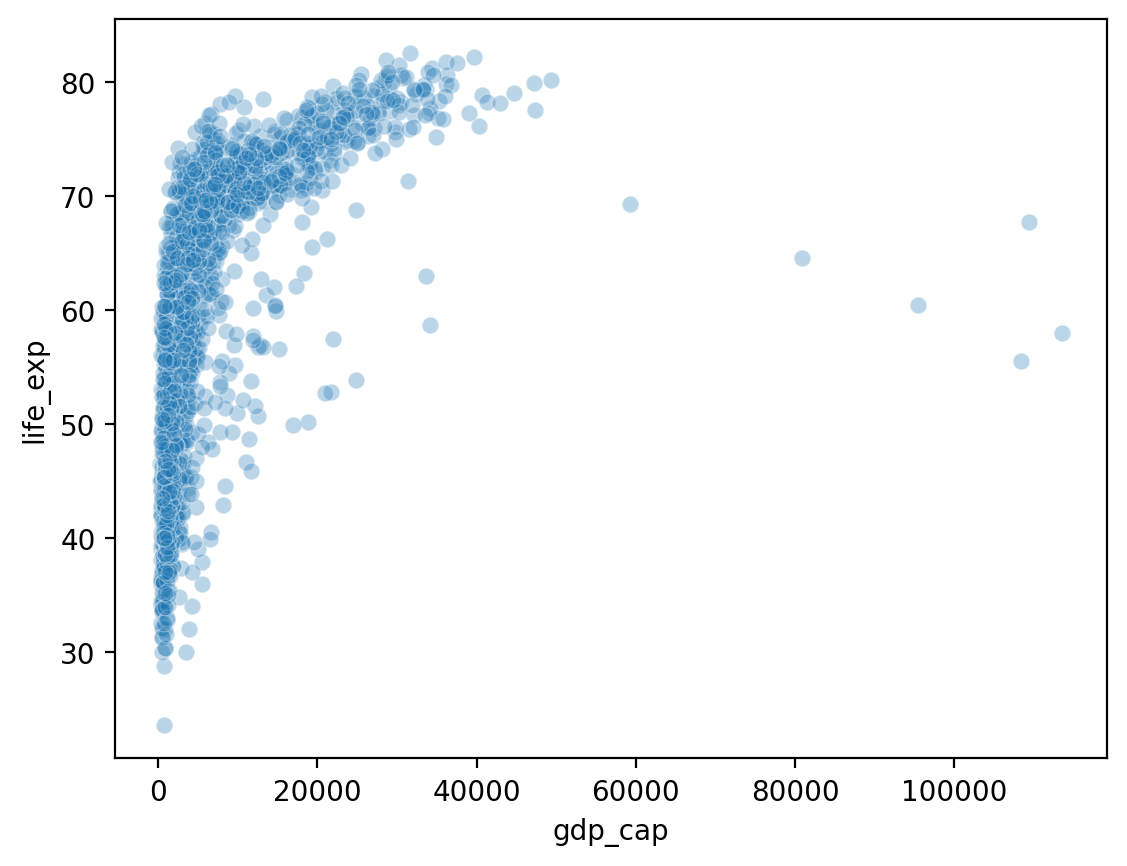

In [15]:
sns.scatterplot(data = df_gapminder, x = 'gdp_cap',
               y = 'life_exp', alpha = .3);

#### Showing `gdp_cap_log` by `life_exp`

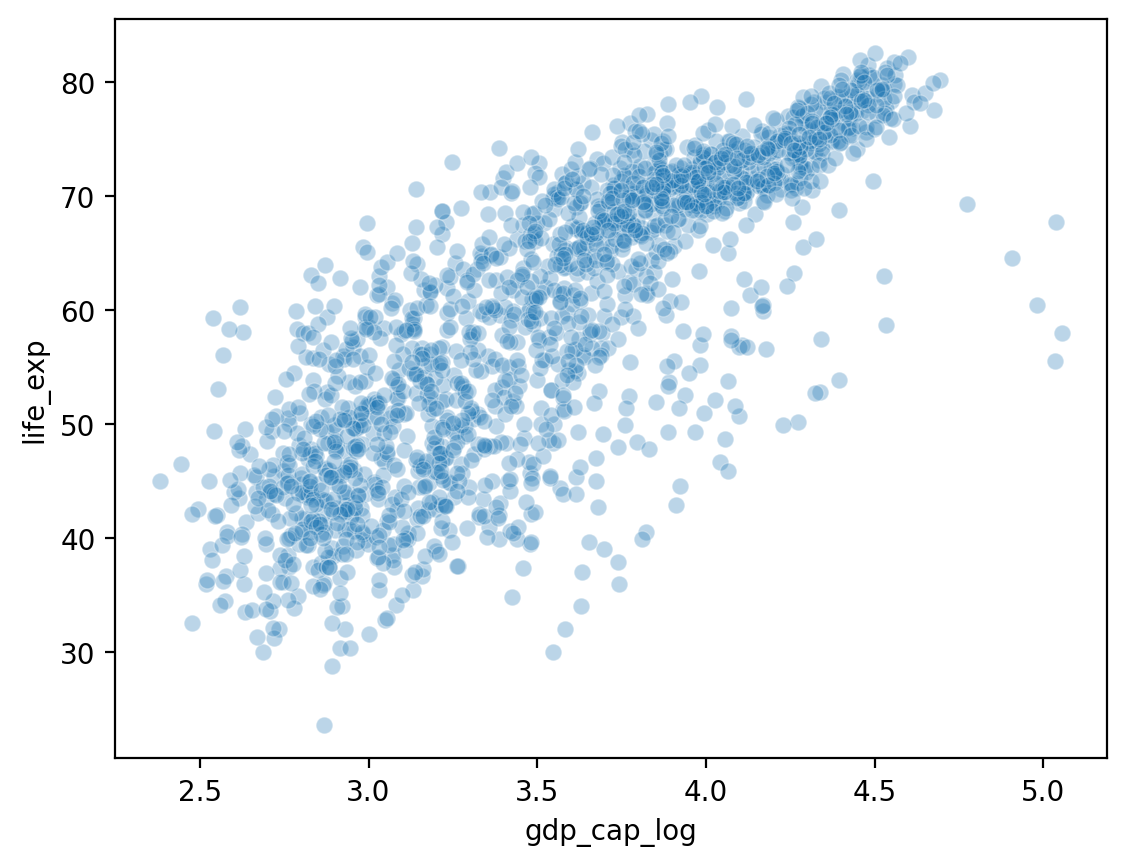

In [16]:
## Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Show log GDP by life exp
sns.scatterplot(data = df_gapminder, x = 'gdp_cap_log', y = 'life_exp', alpha = .3);

#### Adding a `hue`

- What if we want to add a *third* component that's categorical, like `continent`?
- `seaborn` allows us to do this with `hue`.

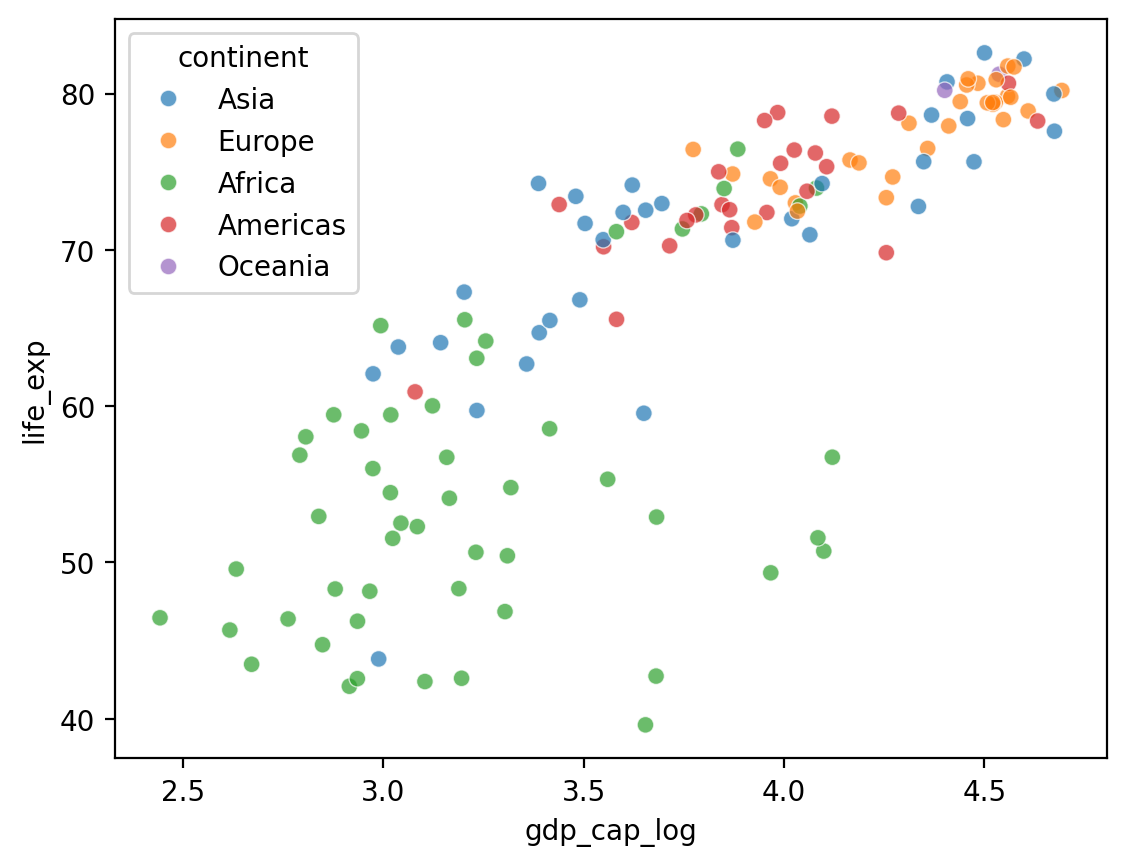

In [17]:
## Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Show log GDP by life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp', hue = "continent", alpha = .7);

#### Adding a `size`

- What if we want to add a *fourth* component that's continuous, like `population`?
- `seaborn` allows us to do this with `size`.

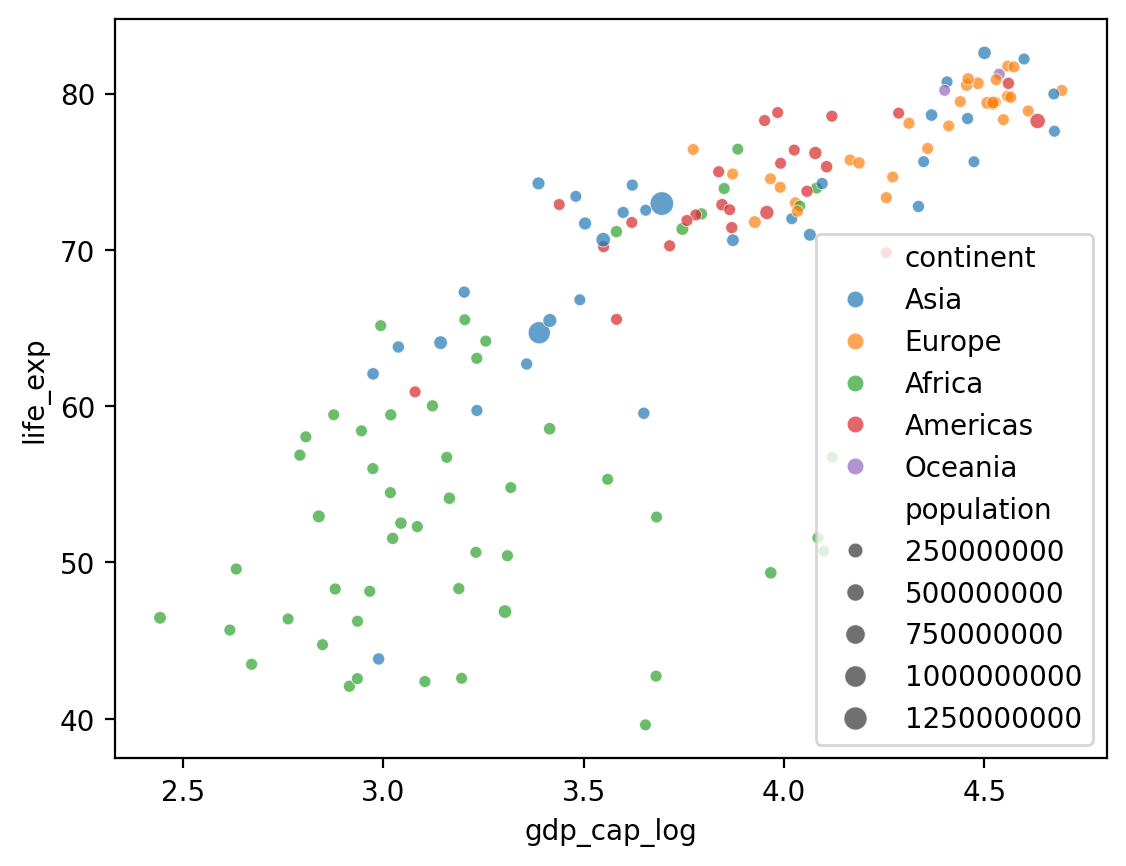

In [18]:
## Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Show log GDP by life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp',
                hue = "continent", size = 'population', alpha = .7);

#### Changing the position of the legend

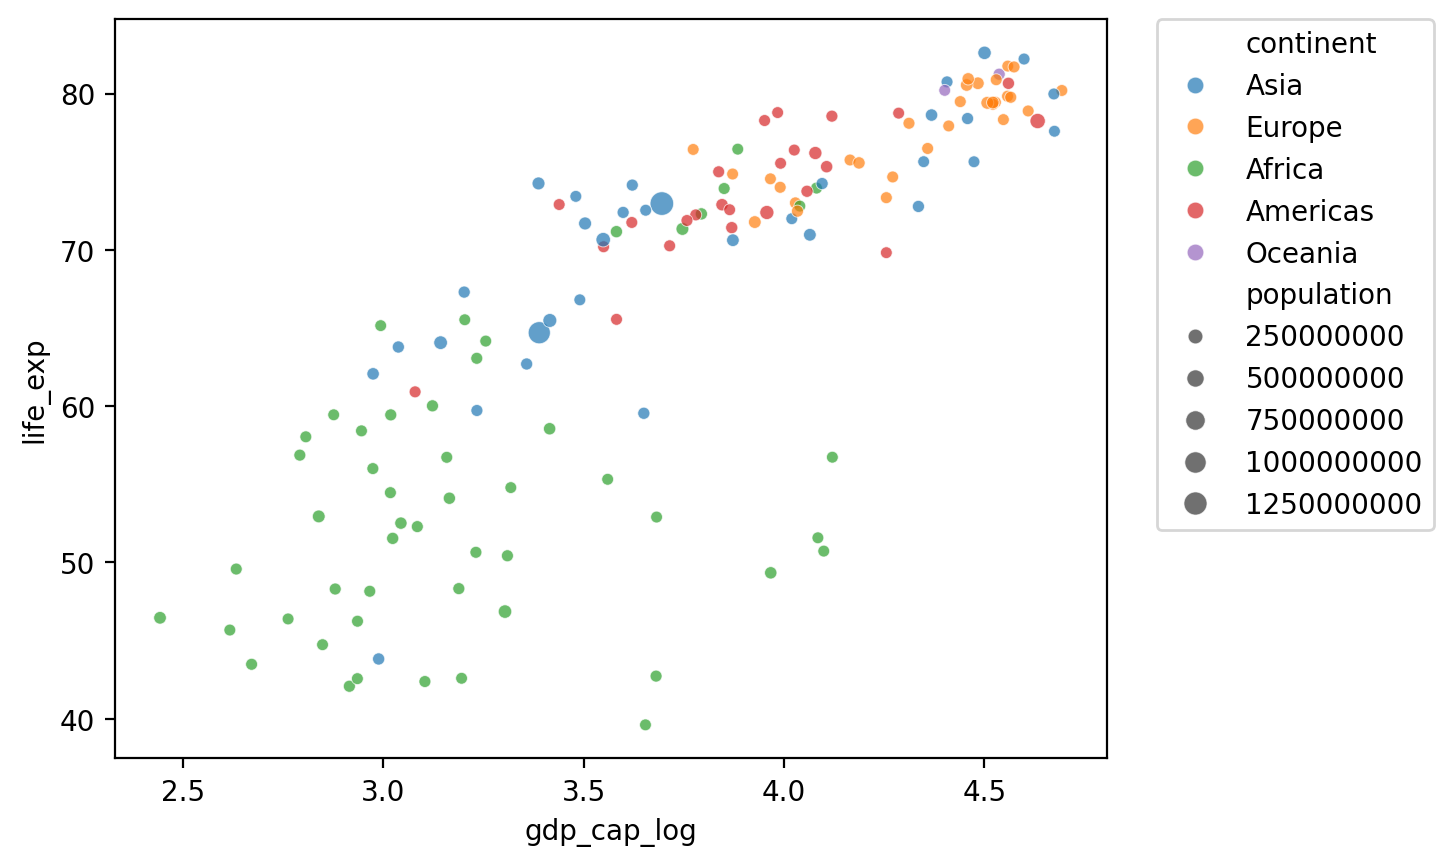

In [20]:
## Show log GDP by life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp',
                hue = "continent", size = 'population', alpha = .7);

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0);

### Lineplots with `sns.lineplot`

> A **lineplot** also visualizes the relationship between two continuous variables.

- Typically, the position of the line on the `y` axis reflects the *mean* of the `y`-axis variable for that value of `x`.
- Often used for plotting **change over time**.

One way to make a lineplot in `seaborn` is using [`sns.lineplot`](https://seaborn.pydata.org/generated/seaborn.lineplot.html).

#### Showing `life_exp` by `year`

What general trend do we notice?

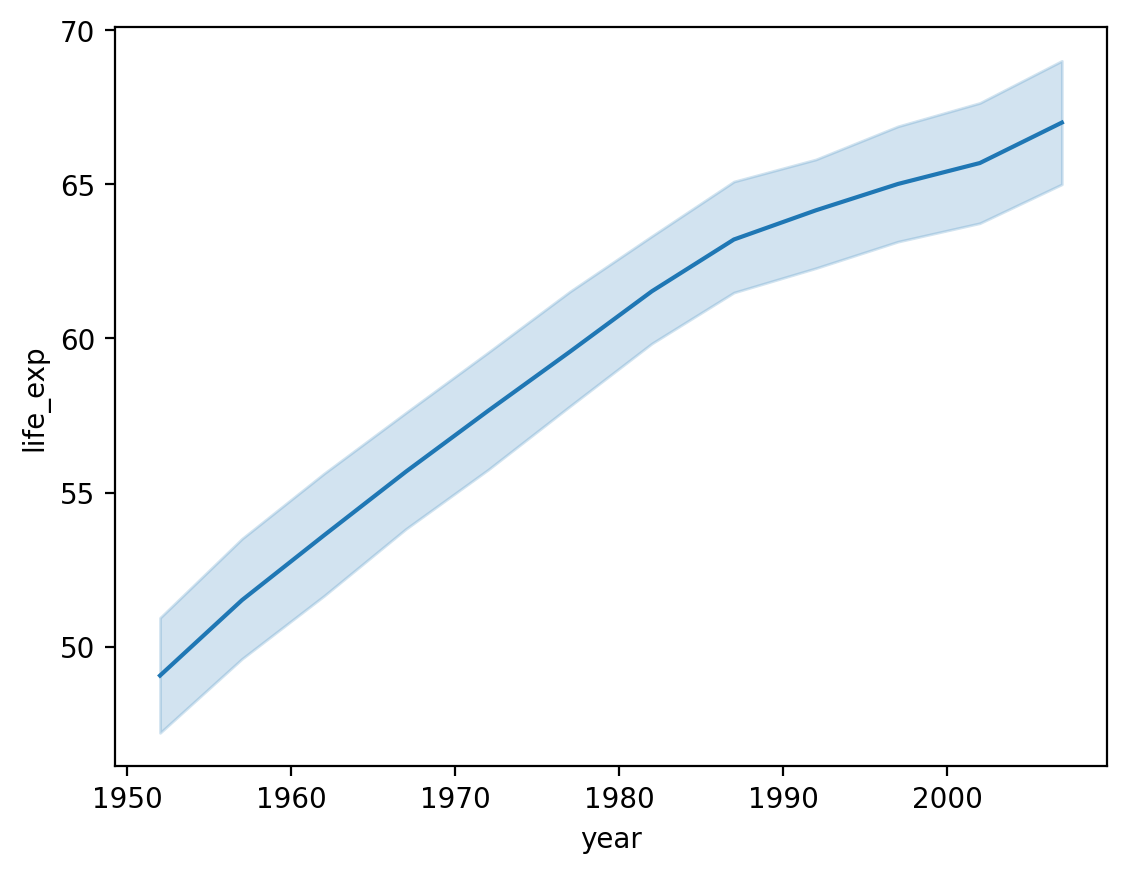

In [21]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp');

#### Modifying how error/uncertainty is displayed

- By default, `seaborn.lineplot` will draw **shading** around the line representing a confidence interval.
- We can change this with `errstyle`.

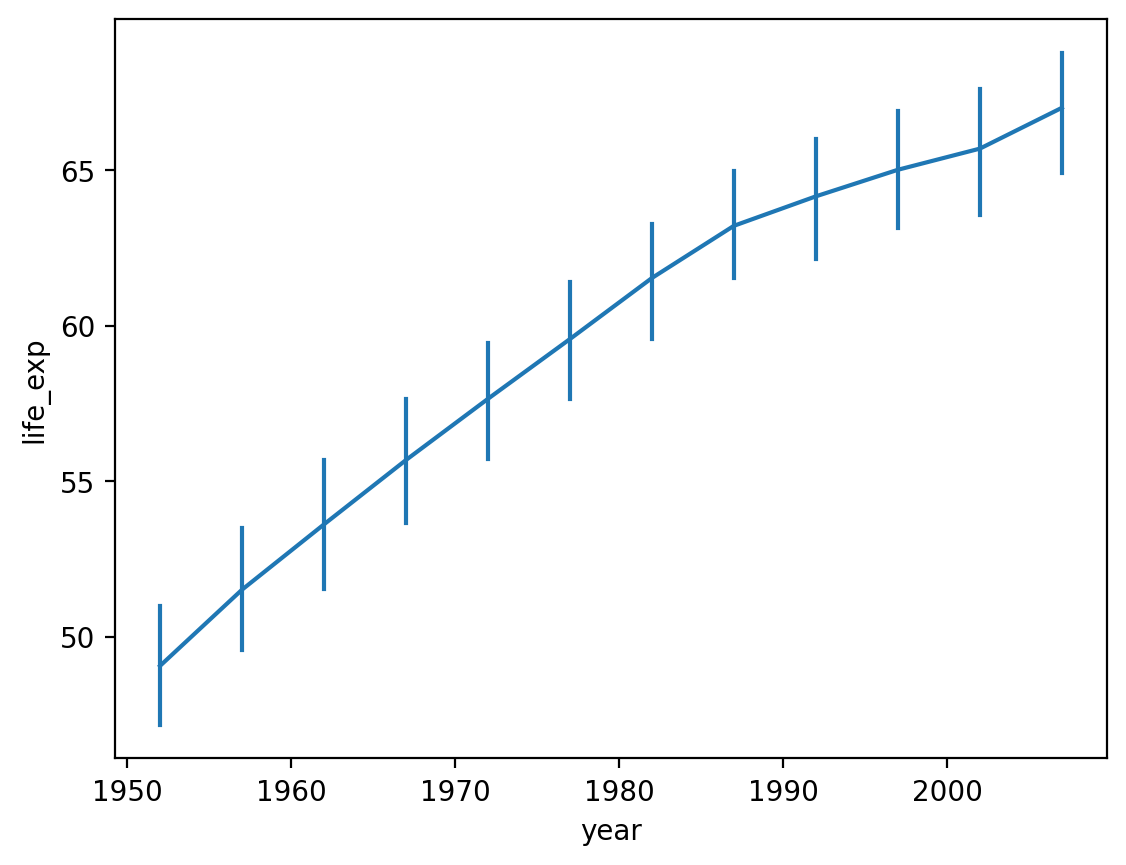

In [22]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp',
            err_style = "bars");

#### Adding a `hue`

- We could also show this by `continent`.  
- There's (fortunately) a positive trend line for each `continent`.

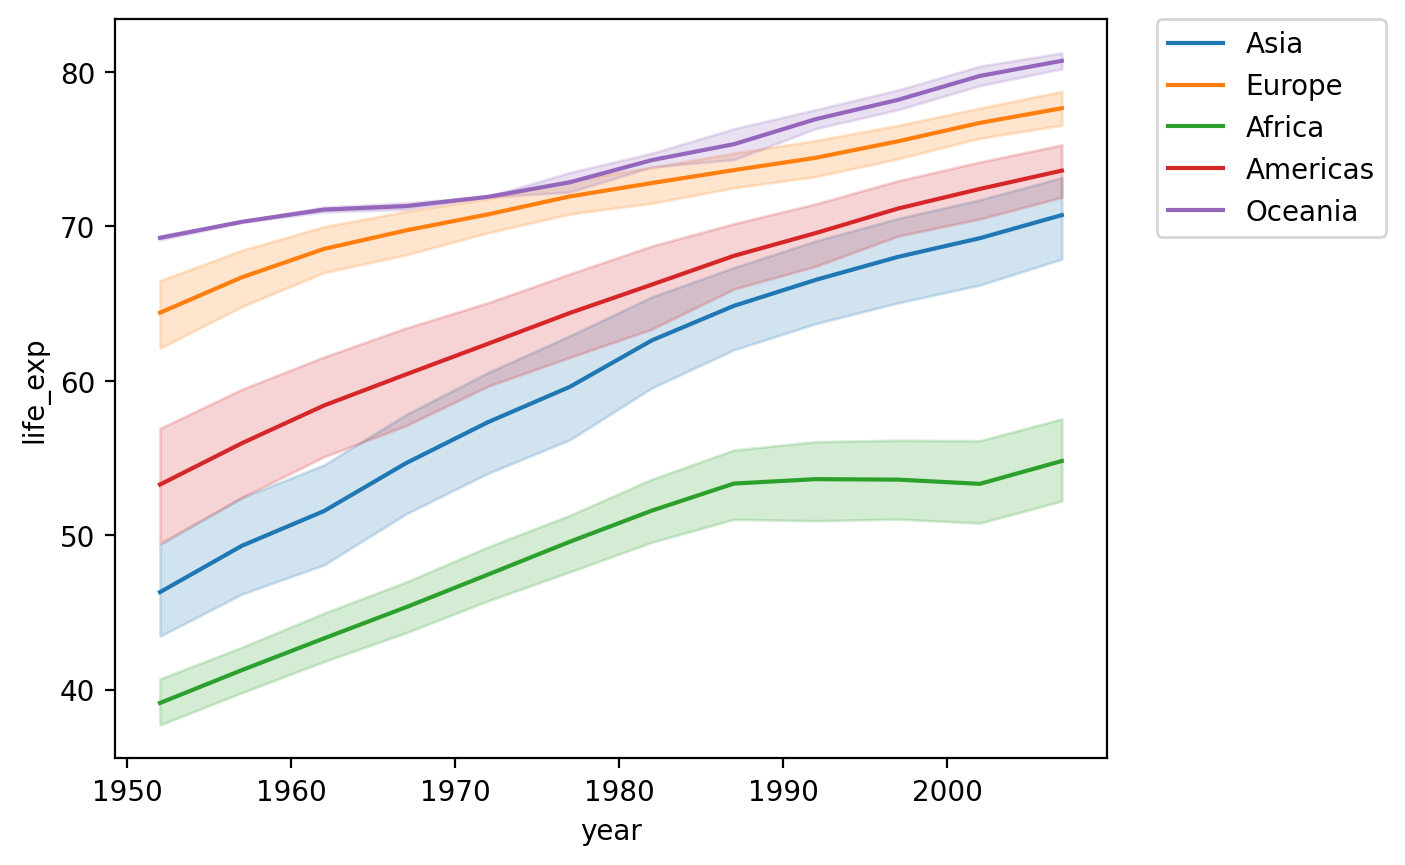

In [23]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp',
            hue = "continent")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0);

#### Check-in

How would you plot the relationship between `year` and `gdp_cap` for countries in the `Americas` only?

In [48]:
### Your code here

#### Solution

What do we notice about:

- The overall trend line?
- The **error bands** as `year` increases?

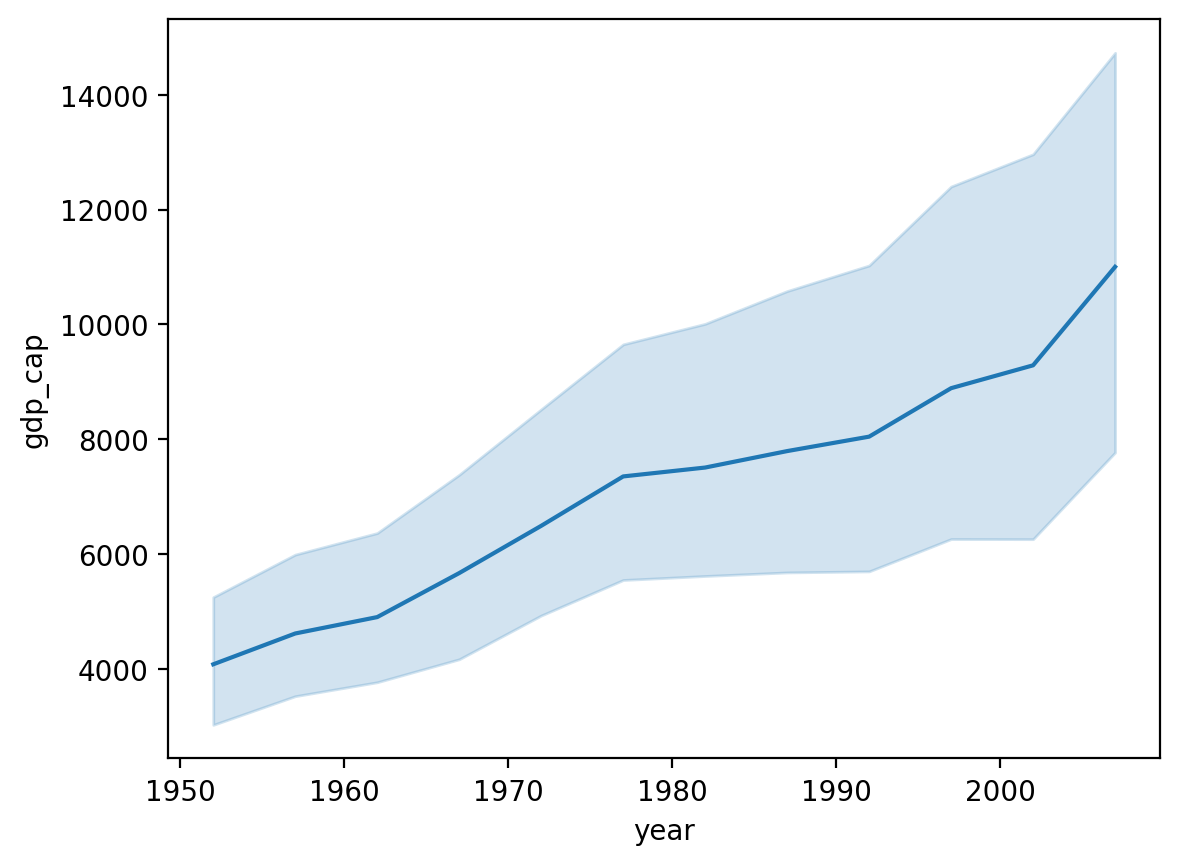

In [24]:
sns.lineplot(data = df_gapminder[df_gapminder['continent']=="Americas"],
             x = 'year',
             y = 'gdp_cap');

#### Heteroskedasticity in `gdp_cap` by `year`

- [**Heteroskedasticity**](https://en.wikipedia.org/wiki/Homoscedasticity_and_heteroscedasticity) is when the *variance* in one variable (e.g., `gdp_cap`) changes as a function of another variable (e.g., `year`).
- In this case, why do you think that is?

#### Plotting by country

- There are too many countries to clearly display in the `legend`. 
- But the top two lines are the `United States` and `Canada`.
   - I.e., two countries have gotten much wealthier per capita, while the others have not seen the same economic growth.

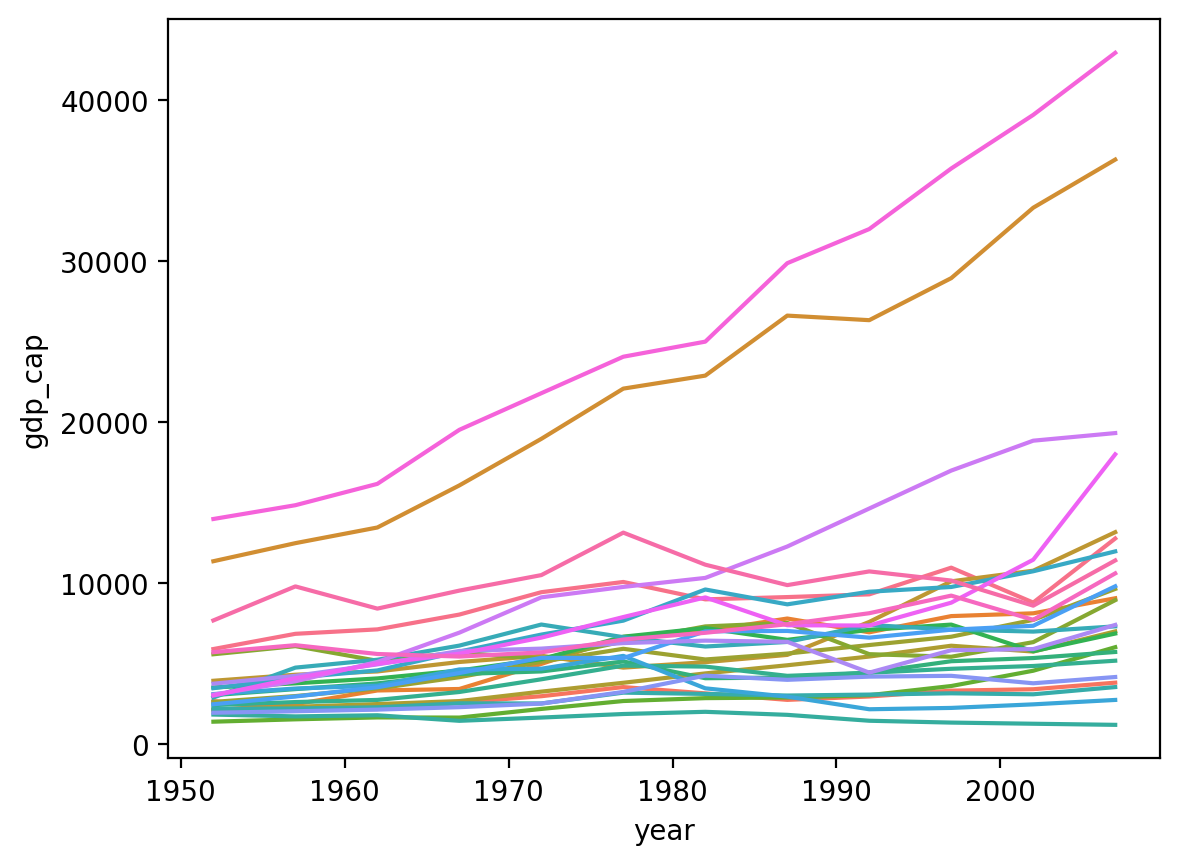

In [25]:
sns.lineplot(data = df_gapminder[df_gapminder['continent']=="Americas"],
             x = 'year', y = 'gdp_cap', hue = "country", legend = None);

### Using `replot`

- `relplot` allows you to plot either line plots or scatter plots using `kind`.
- `relplot` also makes it easier to `facet` (which we'll discuss momentarily).

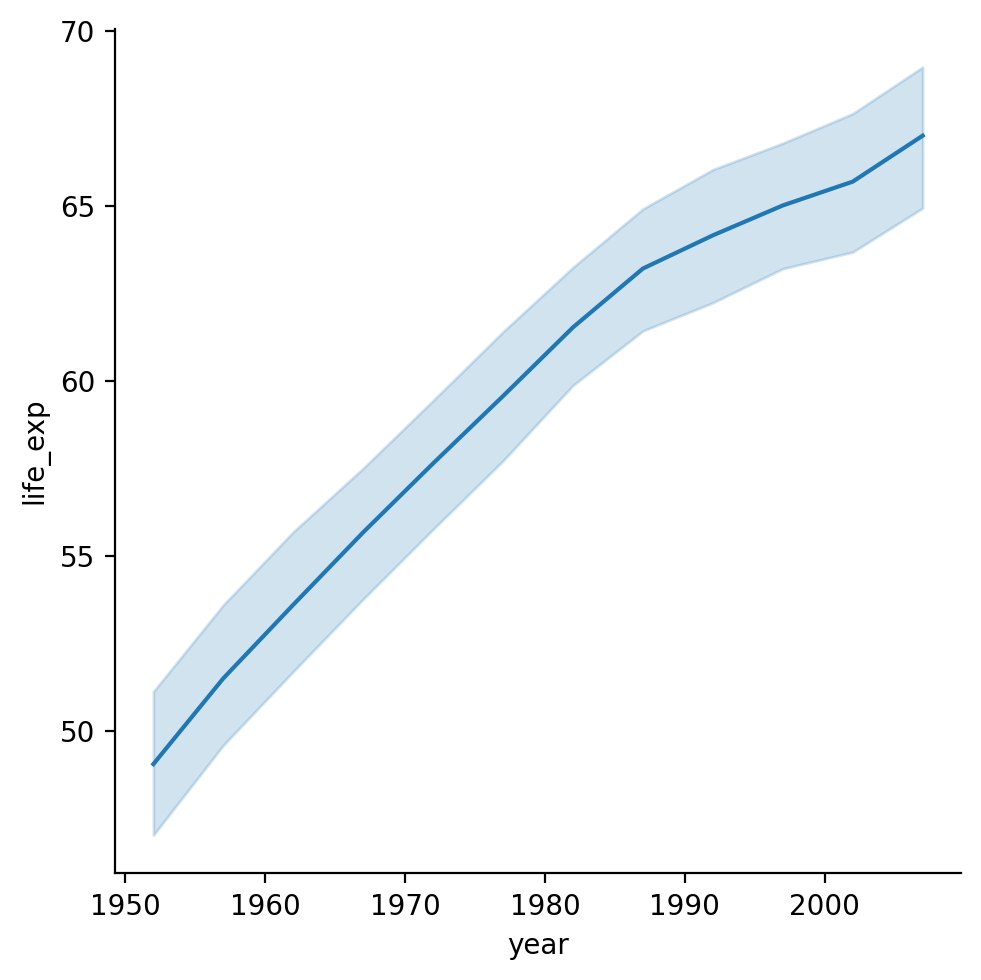

In [26]:
sns.relplot(data = df_gapminder, x = "year", y = "life_exp", kind = "line");

#### Faceting into `rows` and `cols`

We can also plot the same relationship across multiple "windows" or **facets** by adding a `rows`/`cols` parameter.

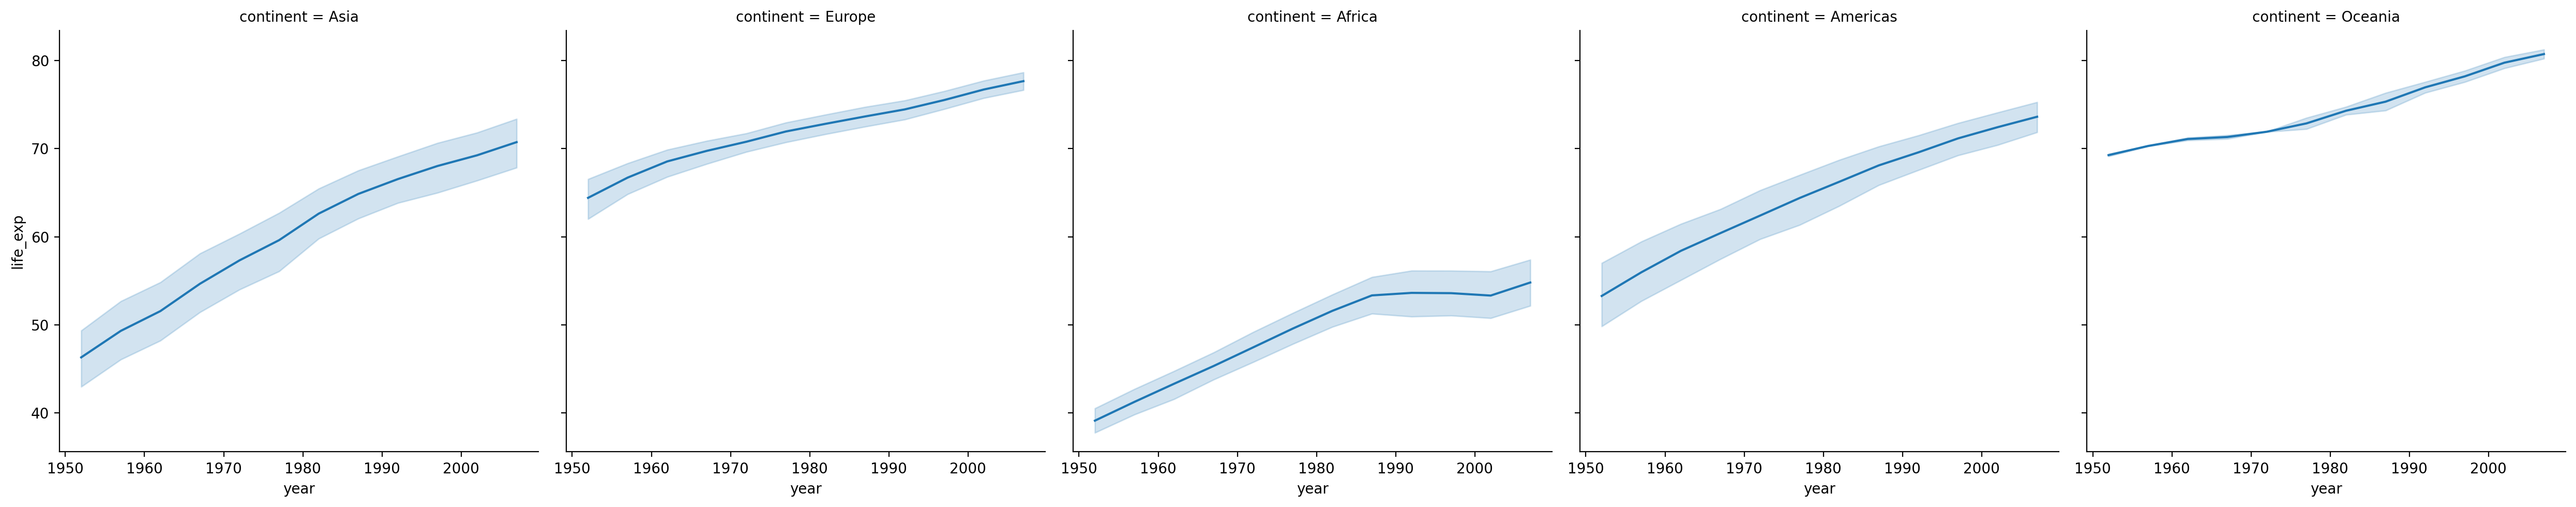

In [27]:
sns.relplot(data = df_gapminder, x = "year", y = "life_exp", kind = "line", col = "continent");

## Bivariate categorical plots

> A **bivariate categorical plot** visualizes the relationship between one categorical variable and one continuous variable.

![title](img/seaborn_catplot.png)

### Example dataset

Here, we'll return to our Pokemon dataset, which has more examples of categorical variables.

In [28]:
df_pokemon = pd.read_csv("data/pokemon.csv")

### Barplots with `sns.barplot`

> A **barplot** visualizes the relationship between one *continuous* variable and a *categorical* variable.

- The *height* of each bar generally indicates the mean of the continuous variable.
- Each bar represents a different *level* of the categorical variable.

With `seaborn`, we can use the function `sns.barplot`.

#### Average `Attack` by `Legendary` status

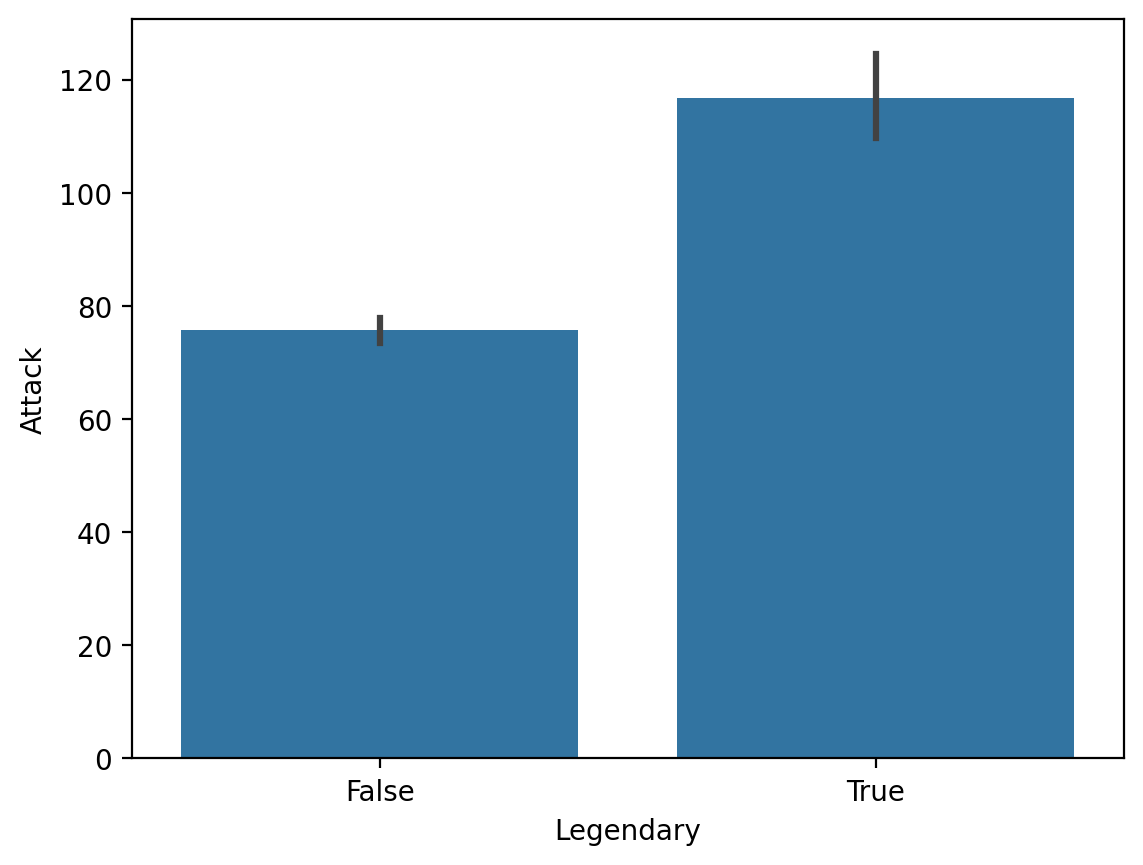

In [29]:
sns.barplot(data = df_pokemon,
           x = "Legendary", y = "Attack");

#### Average `Attack` by `Type 1`

Here, notice that I make the figure *bigger*, to make sure the labels all fit.

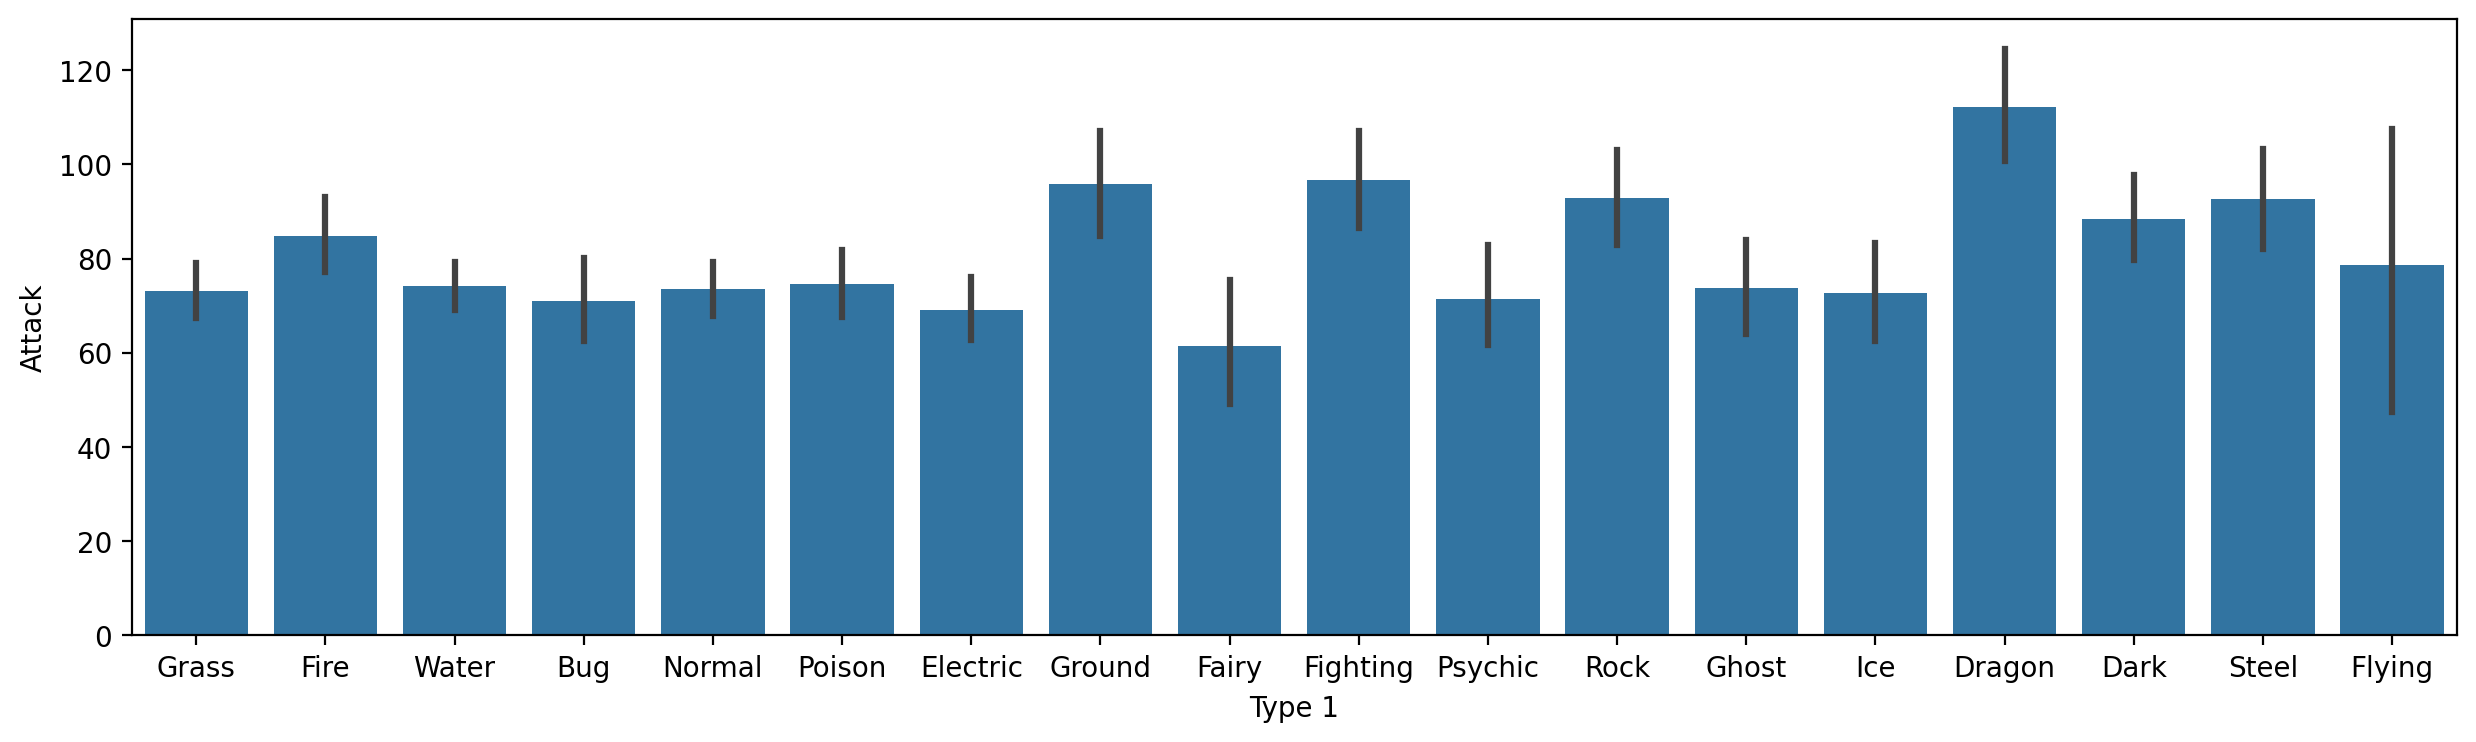

In [30]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_pokemon,
           x = "Type 1", y = "Attack");

#### Check-in

How would you plot `HP` by `Type 1`?

In [56]:
### Your code here

#### Solution

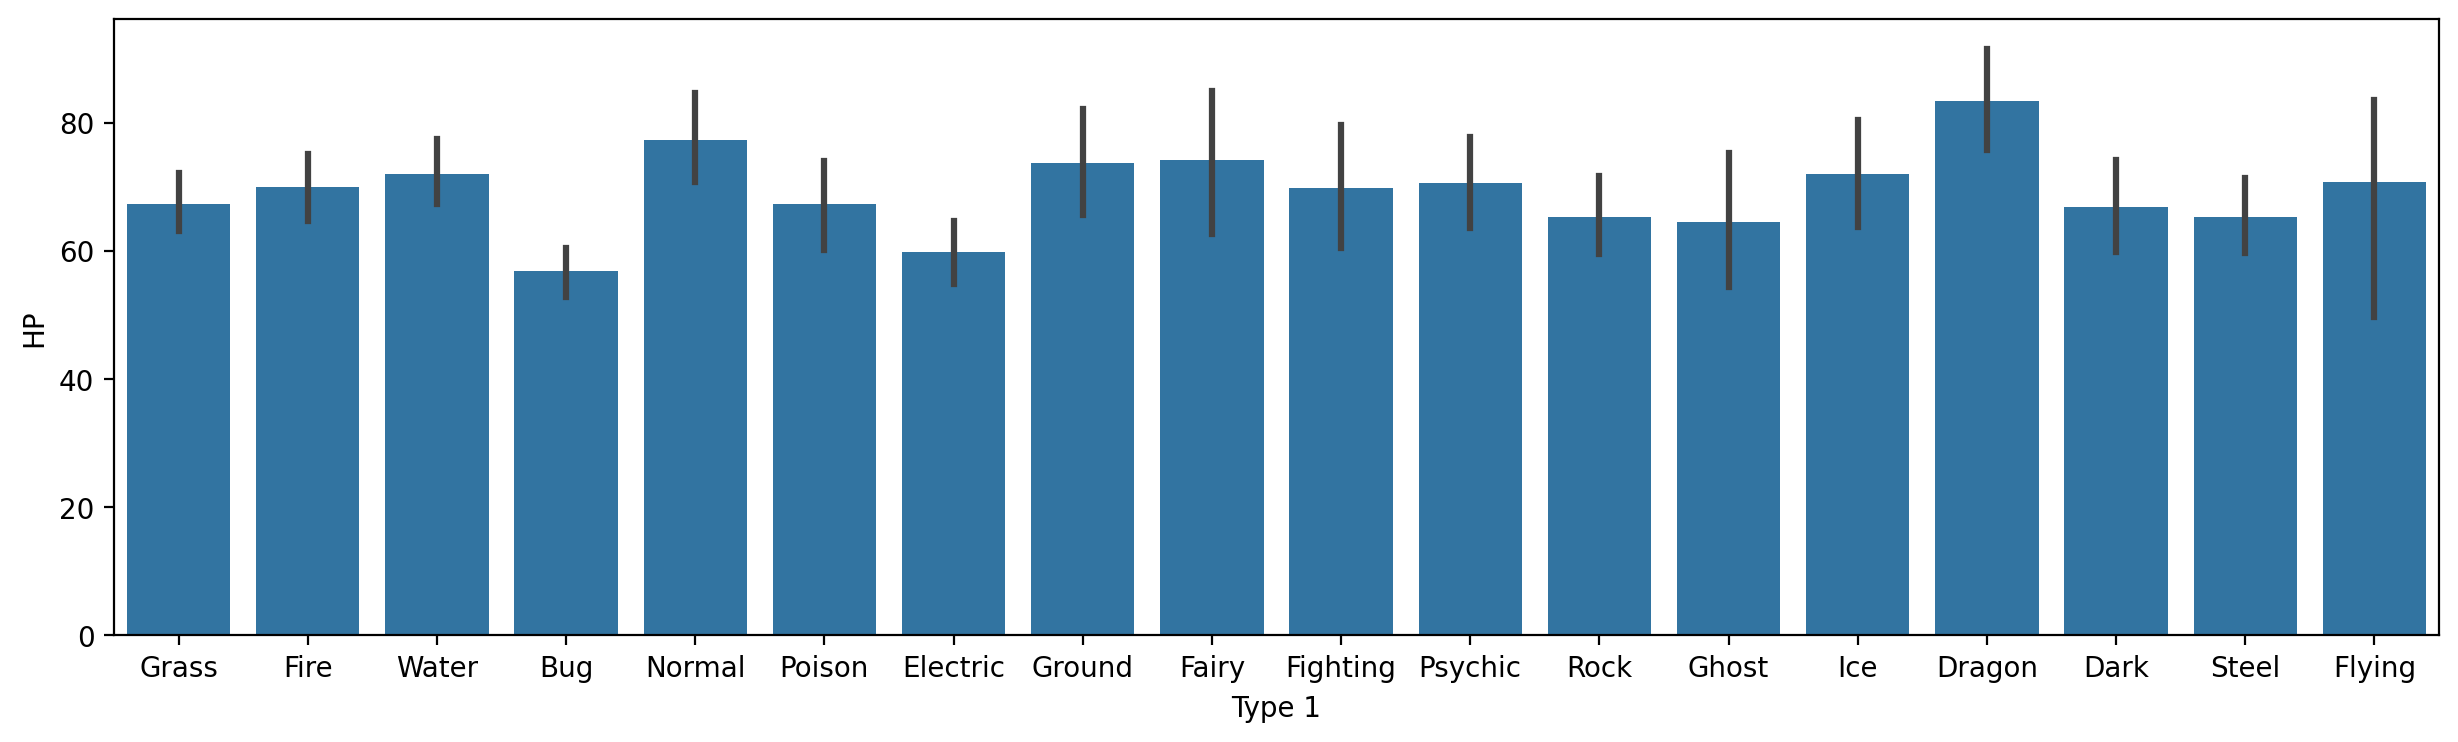

In [31]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_pokemon,
           x = "Type 1", y = "HP");

#### Modifying `hue`

As with `scatterplot` and `lineplot`, we can change the `hue` to give further granularity.

- E.g., `HP` by `Type 1`, further divided by `Legendary` status.

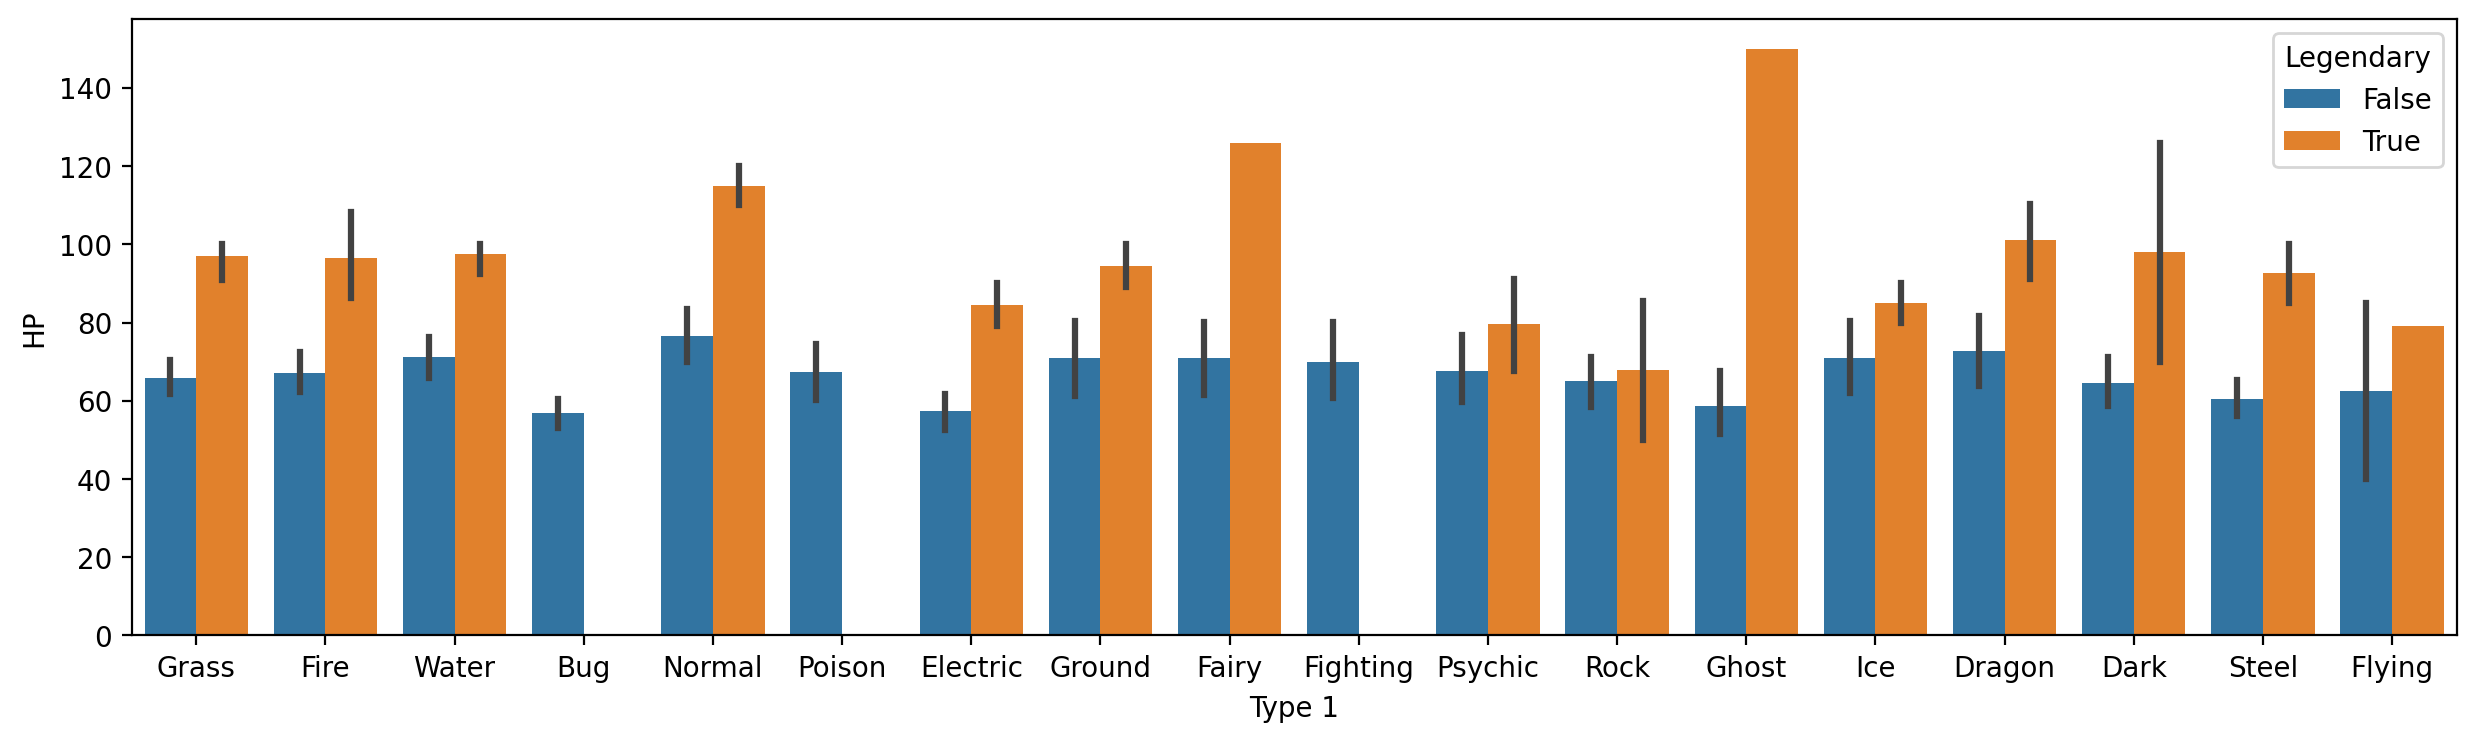

In [32]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_pokemon,
           x = "Type 1", y = "HP", hue = "Legendary");

### Using `catplot`

> `seaborn.catplot` is a convenient function for plotting bivariate categorical data using a range of plot types (`bar`, `box`, `strip`).

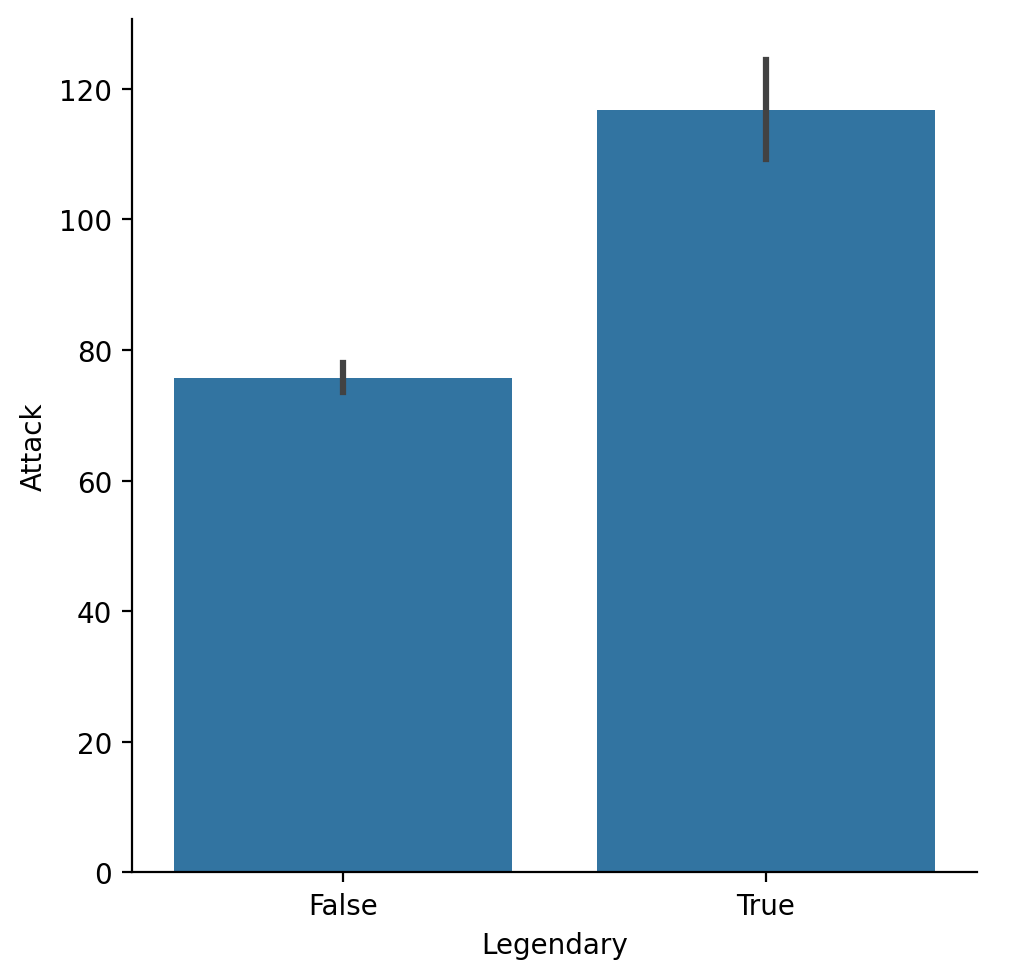

In [33]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "bar");

#### `strip` plots

> A `strip` plot shows each individual point (like a scatterplot), divided by a **category label**.

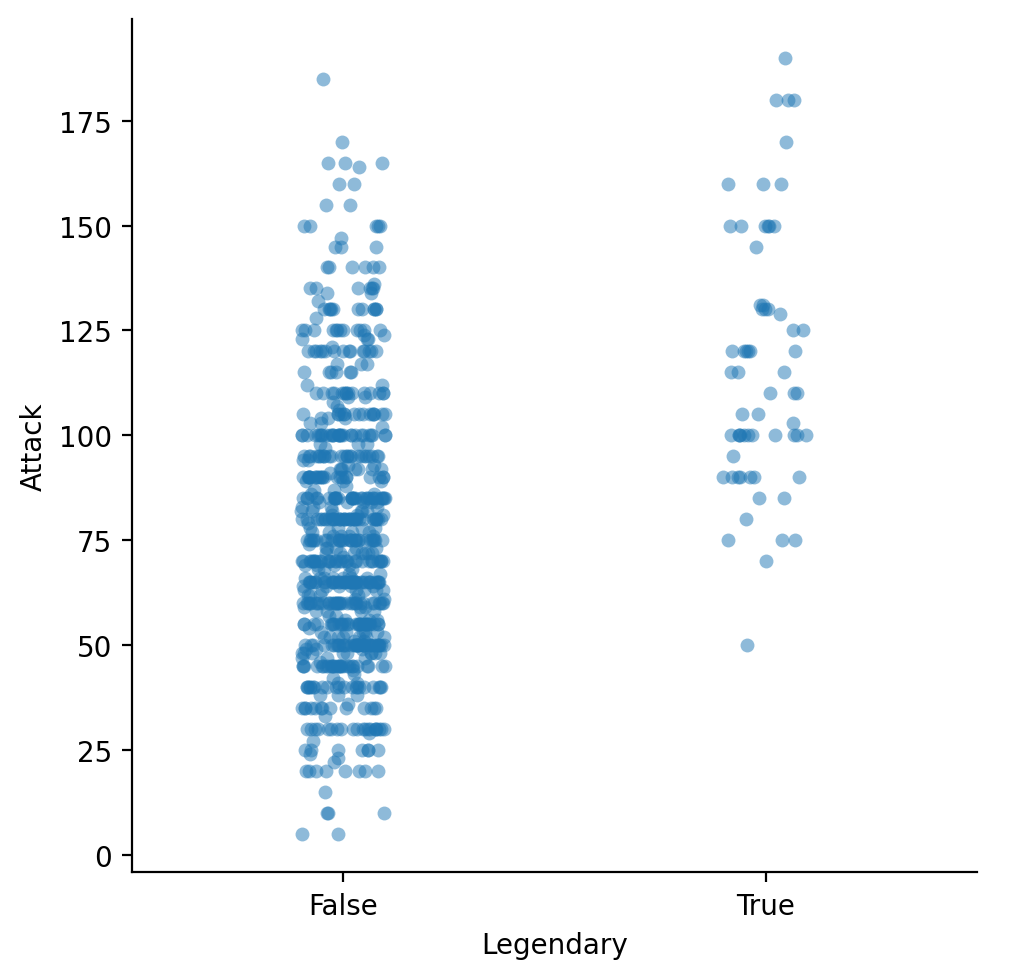

In [34]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "strip", alpha = .5);

#### Adding a `mean` to our `strip` plot

We can plot *two graphs* at the same time, showing both the individual points and the means.

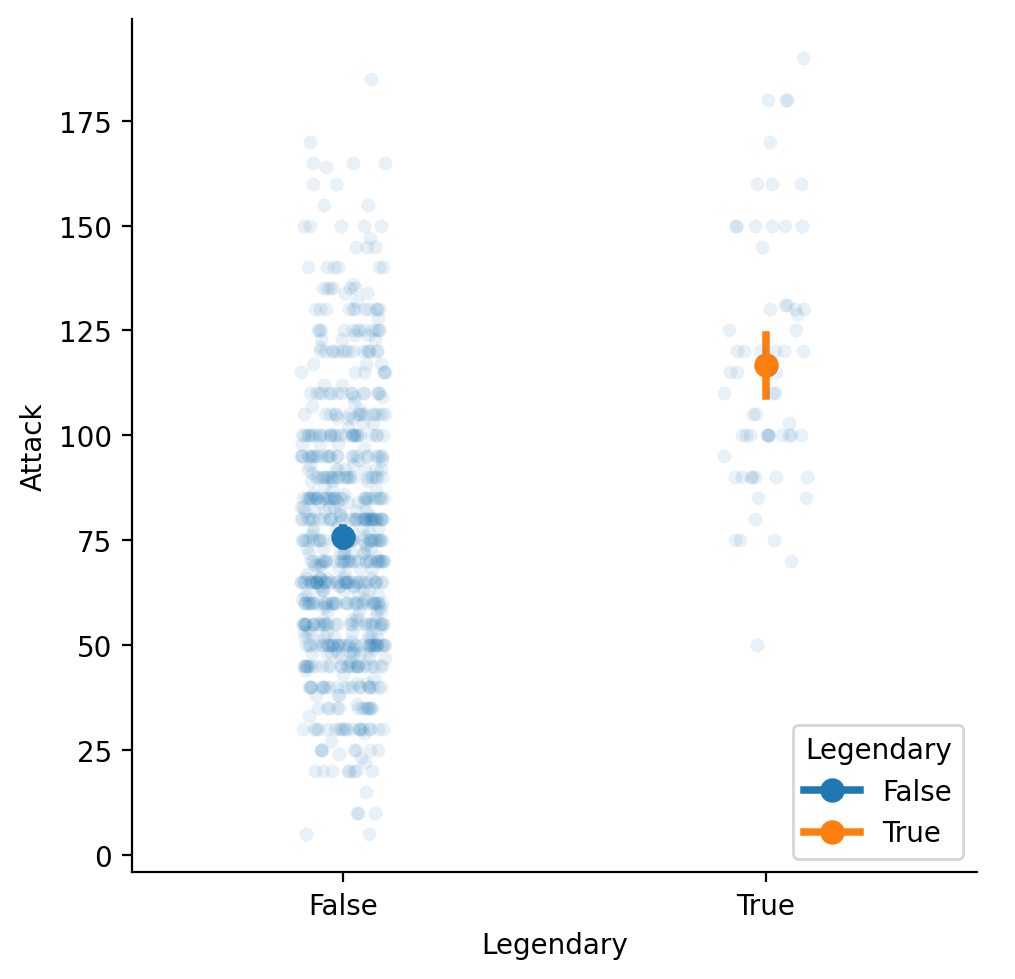

In [35]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "strip", alpha = .1);
sns.pointplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", hue = "Legendary");

#### `box` plots

> A `box` plot shows the interquartile range (the middle 50% of the data), along with the minimum and maximum.

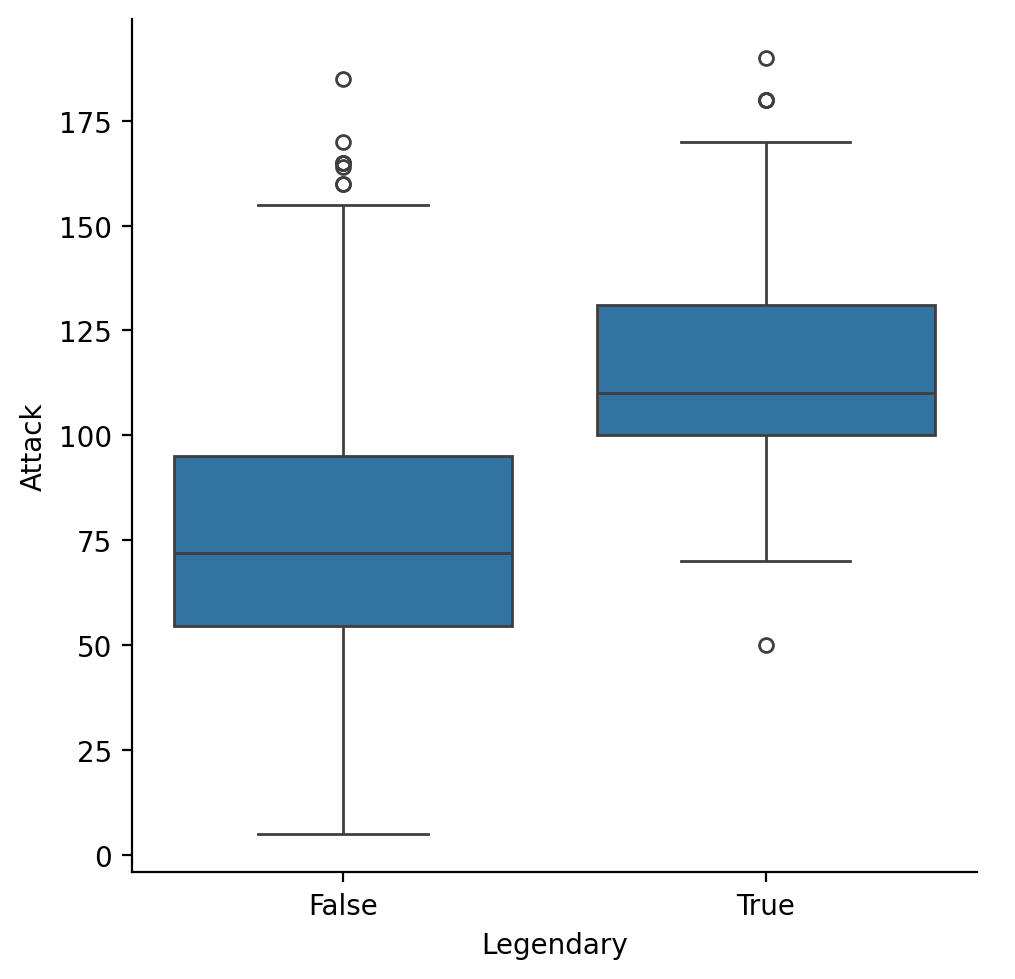

In [37]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "box");

> A **boxplot** theoretically shows the interquartile range (the middle 50% of the data), the median, along with the minimum and maximum.

A typical **boxplot** has several components that are part of its anatomy:

- Median: This is the middle value of the data, represented by a line in a box.
- Boxes: These represent the interquartile range (IQR) of the data, which represents the range between Q1 and Q3. The lower and upper edges represent Q1 and Q3, respectively.
- Whiskers: These are vertical lines that extend from either end of the box to represent the minimum and maximum values, excluding outliers.
- Outliers: These are points outside the whiskers that are considered unusual or extreme compared to the rest of the data.
- Boundaries: These are horizontal lines at the ends of the whiskers, representing the minimum and maximum values, including any outliers.

**Do the whiskers show the minimum and maximum?**

From a statistical point of view - the ends of the whiskers are therefore not min and max - because they do not contain some of the anomalous values.

*Standard rules:*

- **Outliers:** These are the points that are outside the whisker range. These values ​​are considered anomalous compared to the rest of the data.
- **Whisker range:** The whiskers extend to values ​​that fall within the following limits:
- Lower whisker: $Q1 - 1.5 * IQR$
- Upper whisker: $Q3 + 1.5 * IQR$
- **Extreme outliers:** If the values ​​are much further outside the whiskers (e.g. $Q1 - 3 * IQR$ or $Q3 + 3 * IQR$), they can be considered extreme outliers.

Outliers are typically displayed as single points on a box plot, making them easy to identify.

**Why are outliers important?**

- They can indicate errors in the data (e.g., typos, measurement errors).

- They can represent real but rare events that are worth investigating.

- Outliers can significantly affect descriptive statistics, such as the mean, so identifying them is crucial to data analysis.

**Why 1.5 × IQR?**

$1.5$ × $IQR$ is a standard value used to identify moderate outliers.

The interquartile range (IQR) is the difference between the third quartile (Q3) and the first quartile (Q1), the range in which the middle 50% of the data fall.

Values ​​that are outside the range:

- Lower threshold: $Q1$ - $1.5$ × $IQR$
- Upper threshold: $Q3$ + $1.5$ × $IQR$ are considered outliers.

The value $1.5$ was empirically chosen as a reasonable compromise between detecting outliers and ignoring natural fluctuations in the data.

**Why 3 × IQR?**

$3$ × $IQR$ is used to identify extreme outliers that are much more distant from the rest of the data.

Values ​​outside the range:

- Lower threshold: $Q1$ - $3$ × $IQR$
- Upper threshold: $Q3$ + $3$ × $IQR$ are considered extreme outliers.

The $3$ × $IQR$ value is more stringent and allows for the identification of points that are highly unusual and may indicate errors in the data or rare events.

You can of course easily plot one variable and its box plot:

In [38]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


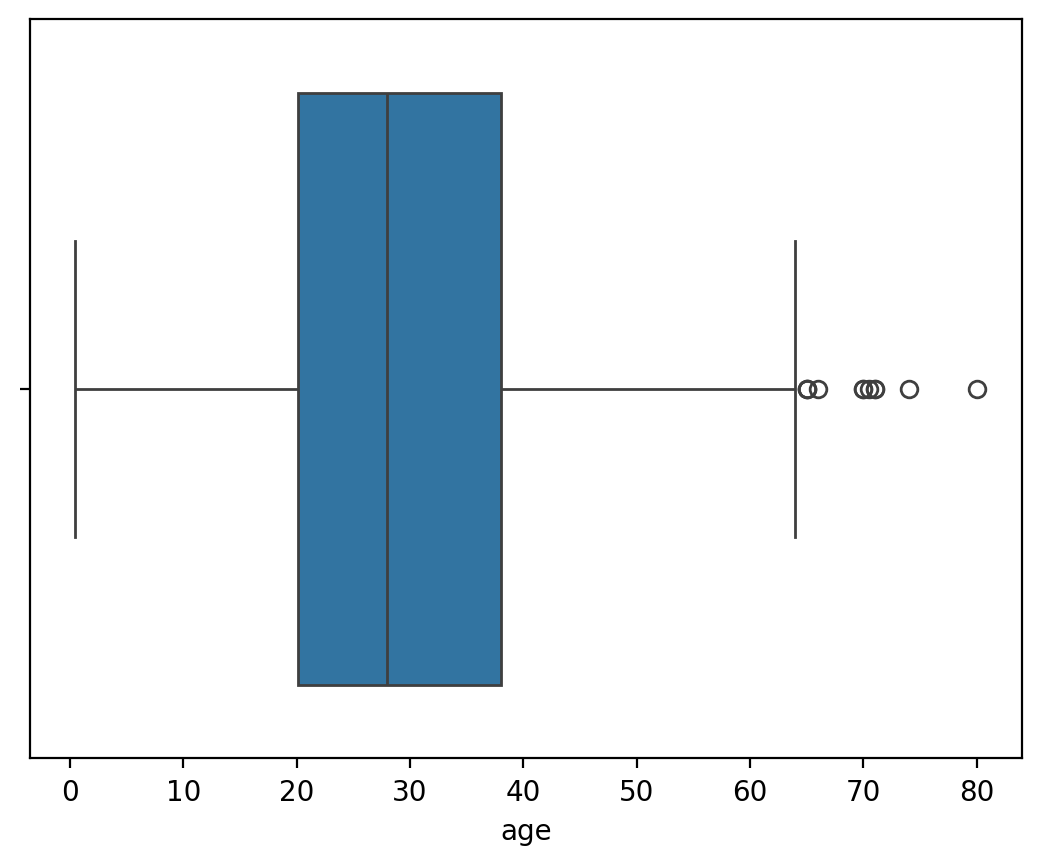

In [39]:
sns.boxplot(x=titanic["age"]);

We will now group the boxplot by categorical variable by referencing the columns in the data frame:

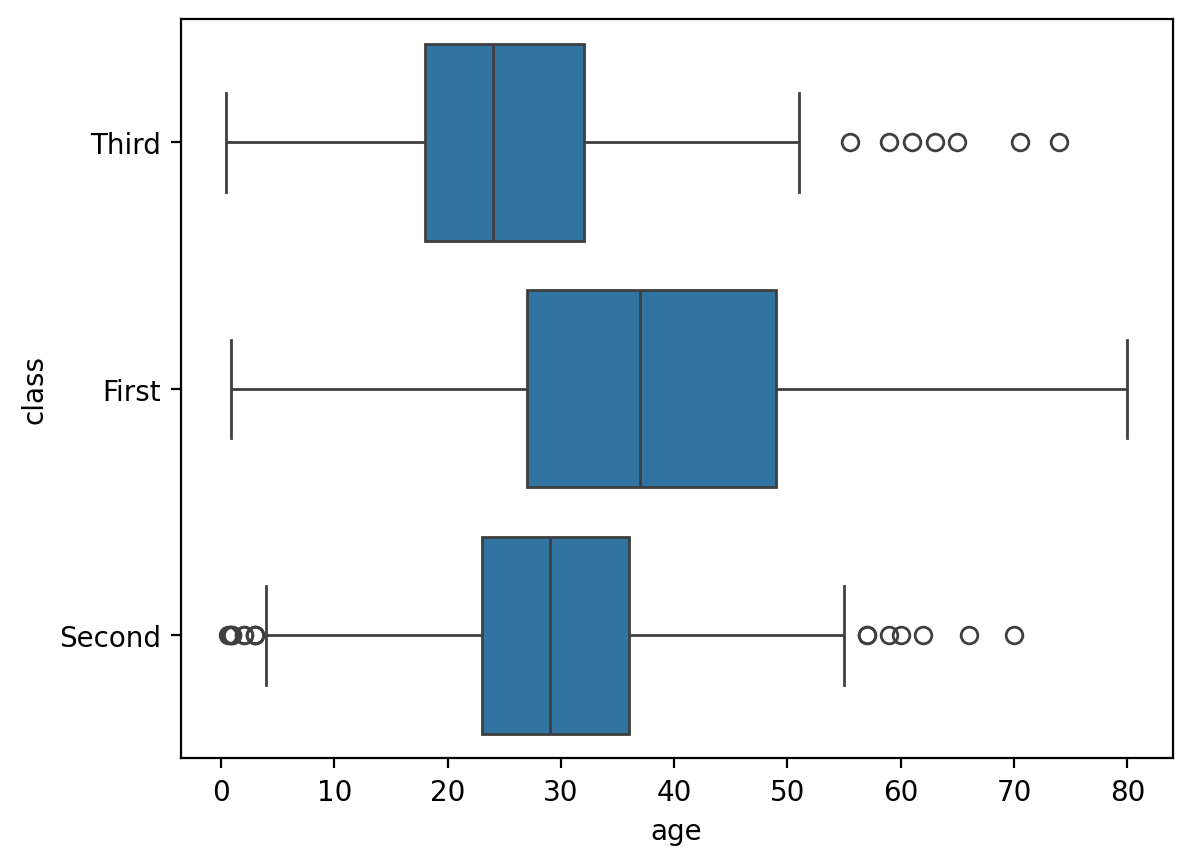

In [40]:
sns.boxplot(data=titanic, x="age", y="class");

Let's draw a vertical box plot with nested grouping by two variables:

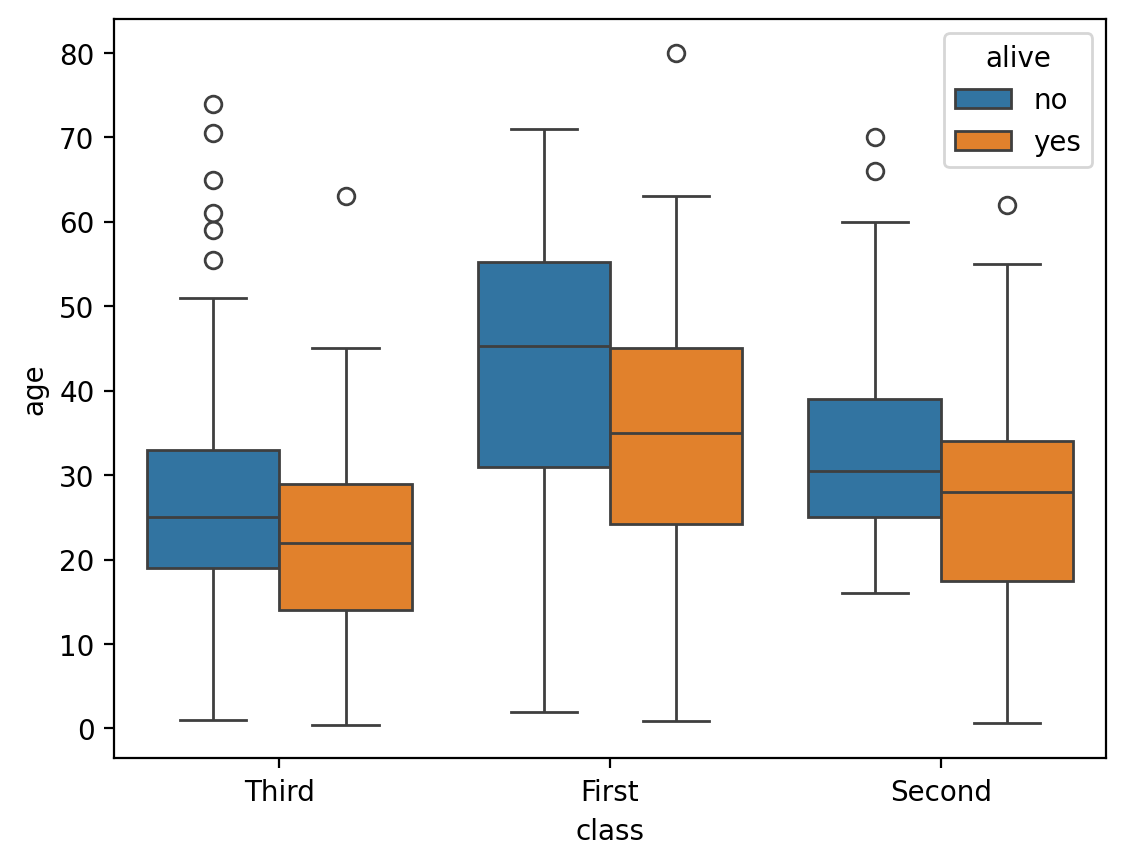

In [41]:
sns.boxplot(data=titanic, x="class", y="age", hue="alive");

See also how to draw treble clef plots, so-called swarm plots (similar to strip plots) - more information [here](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

## Conclusion

As with our lecture on `pyplot`, this just scratches the surface.

But now, you've had an introduction to:

- The `seaborn` package.
- Plotting both **univariate** and **bivariate** data.
- Creating plots with multiple layers.